# 自身分析

##  1.1 各段uplift

In [9]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# ==========================================
# 1. 核心配置与路径管理
# ==========================================
OUTPUT_DIR = "0414_analyze_internal"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"
C_PRIOR_PATH = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv"

# 你的所有待测模型
MODELS_TO_EVALUATE = {
    "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    'V8_S5': f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv", 
    "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

SLICES = [
    (0, 5), (5, 10), (10, 20),
    #   (0, 20),
    # (20, 50), (50, 100),
    #   (20, 100)
    (20, 30), 
    (30, 40), (40, 50), (50, 75), (75, 100)
]

# ==========================================
# 2. 加载大盘独立 C 先验 (确保行数对齐)
# ==========================================
print("📥 正在加载独立 C 模型先验与真实 C 标签...")
c_file = glob.glob(C_PRIOR_PATH, recursive=True)[0]
df_c_indep = pd.read_csv(c_file)

# 提取独立的 Pred C 和 True C
INDEP_PRED_C = df_c_indep['y1_prob'] - df_c_indep['y0_prob']
TRUE_C = df_c_indep['c_true']

# ==========================================
# 3. 核心算子：区间内 Local AUUC 计算
# ==========================================
def compute_local_auuc(y, t, pred_score):
    """在区间内部，用 pred_score 重新排序，并计算 AUUC"""
    if len(y) < 2: return 0.0
    
    # 内部重新排序
    order = np.argsort(pred_score)[::-1]
    y_s, t_s = y[order], t[order]
    
    n_t = np.cumsum(t_s == 1); n_c = np.cumsum(t_s == 0)
    y_t = np.cumsum(y_s * (t_s == 1)); y_c = np.cumsum(y_s * (t_s == 0))
    
    n_t_safe = np.where(n_t == 0, 1e-6, n_t)
    n_c_safe = np.where(n_c == 0, 1e-6, n_c)
    
    with np.errstate(invalid='ignore', divide='ignore'):
        curve = (y_t / n_t_safe - y_c / n_c_safe) * (n_t + n_c)
    curve = np.nan_to_num(curve)
    
    endpoint = curve[-1]
    if abs(endpoint) > 1e-10:
        curve = curve / abs(endpoint)
        
    x_axis = np.arange(1, len(y_s) + 1) / len(y_s)
    return float(np.trapz(curve, x=x_axis))

def get_ate(y_s, t_s):
    if len(y_s) == 0: return 0.0
    cr_t = np.sum(y_s[t_s == 1]) / (np.sum(t_s == 1) + 1e-9)
    cr_c = np.sum(y_s[t_s == 0]) / (np.sum(t_s == 0) + 1e-9)
    return float(cr_t - cr_c)

# ==========================================
# 4. 数据扫描与解剖分析
# ==========================================
print(f"\n🔍 正在启动模型内部心智解剖器...")

for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: 
        print(f"⚠️ 跳过 {name} (未找到文件)")
        continue
        
    df = pd.read_csv(files[0])
    
    # 🌟 关键：拼接 Pred C 和 True C (在全局打乱排序之前！)
    df['c_true'] = TRUE_C
    if 'c_uplift_pred' in df.columns:
        df['Final_Pred_C'] = df['c_uplift_pred']  # MTL 模型自己预测的
        c_source = "Self-Predicted (MTL)"
    else:
        df['Final_Pred_C'] = INDEP_PRED_C         # 两阶段模型读先验的
        c_source = "Prior (Indep C Model)"
        
    # 全局按预测 Y 降序排列！
    df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
    
    n_total = len(df)
    results = []
    
    for start_pct, end_pct in SLICES:
        s_idx, e_idx = int(n_total * start_pct / 100), int(n_total * end_pct / 100)
        slice_df = df.iloc[s_idx:e_idx]
        
        y_t = slice_df['y_true'].values
        c_t = slice_df['c_true'].values
        t_t = slice_df['t'].values
        pred_y = slice_df['uplift_pred'].values
        pred_c = slice_df['Final_Pred_C'].values
        
        # 支柱 1：本段的 True Y 和 True C Uplift
        true_y_ate = get_ate(y_t, t_t)
        true_c_ate = get_ate(c_t, t_t)
        
        # 支柱 2：本段的平均预测分
        avg_pred_y = pred_y.mean()
        avg_pred_c = pred_c.mean()
        
        # 支柱 3：局部 AUUC 引擎
        local_y_auuc = compute_local_auuc(y_t, t_t, pred_y)     # 自己的预测排自己的 Y
        local_c_auuc = compute_local_auuc(c_t, t_t, pred_c)     # 自己的预测排自己的 C
        proxy_y_auuc = compute_local_auuc(y_t, t_t, pred_c)     # 🌟 强行用 C 的预测去排 Y
        
        # 支柱 4：预测分数的耦合程度
        yc_coupling, _ = spearmanr(pred_y, pred_c)
        if np.isnan(yc_coupling): yc_coupling = 0.0 # 防御性填充
        
        results.append({
            "Slice (%)": f"{start_pct}-{end_pct}",
            "True_Y (ATE)": true_y_ate,
            "True_C (ATE)": true_c_ate,
            "Pred_Y (Avg)": avg_pred_y,
            "Pred_C (Avg)": avg_pred_c,
            # "Local_Y_AUUC": local_y_auuc,
            # "Local_C_AUUC": local_c_auuc,
            # "C-sorted_Y_AUUC": proxy_y_auuc,
            # "Y-C_Coupling (Spearman)": yc_coupling
        })

    df_res = pd.DataFrame(results)
    
    # 打印该模型的专属体检报告
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("\n" + "="*140)
    print(f"🧬 【{name}】 内部因果心智解剖单 | C_Source: {c_source}")
    print("="*140)
    print(df_res.to_string(index=False))
    
    # 落盘保存
    out_csv = os.path.join(OUTPUT_DIR, f"{name}_internal_anatomy.csv")
    df_res.to_csv(out_csv, index=False)

print("\n" + "="*140)
print("🎉 所有模型的局部解剖单已生成，保存在 0414_analyze_internal/ 文件夹中！")
print("💡 自身分析破案指南：")
print("1. 找中介成色：对比【Local_Y_AUUC】和【C-sorted_Y_AUUC】。如果前者远大于后者，说明你的网络牛逼，不抄 C 的作业也能把 Y 排好！")
print("2. 找过度耦合：如果某一段的【C-sorted_Y_AUUC】很低（说明这段里 C 没用），但【Y-C_Coupling】还高达 0.9，说明模型在这一段死脑筋被骗了！")
print("3. 找剥离点：对比 V8 和 MTMT 在头部 (0-5%) 的【Y-C_Coupling】。V8 应该会有一定幅度的下降，这就是网络结构发挥剥离作用的铁证！")

📥 正在加载独立 C 模型先验与真实 C 标签...

🔍 正在启动模型内部心智解剖器...

🧬 【V1_Base】 内部因果心智解剖单 | C_Source: Prior (Indep C Model)
Slice (%)  True_Y (ATE)  True_C (ATE)  Pred_Y (Avg)  Pred_C (Avg)
      0-5       0.01073       0.06168       0.01257       0.06283
     5-10       0.00530       0.02880       0.00173       0.02283
    10-20       0.00054       0.01095       0.00013       0.01266
    20-30       0.00011       0.00450      -0.00005       0.00432
    30-40       0.00019       0.00079      -0.00006       0.00084
    40-50       0.00009      -0.00014      -0.00006       0.00076
    50-75       0.00006       0.00112      -0.00008       0.00104
   75-100       0.00015       0.00409      -0.00010       0.00383

🧬 【MT_Naive_Small】 内部因果心智解剖单 | C_Source: Self-Predicted (MTL)
Slice (%)  True_Y (ATE)  True_C (ATE)  Pred_Y (Avg)  Pred_C (Avg)
      0-5       0.01170       0.06135       0.01489       0.06385
     5-10       0.00346       0.02781       0.00136       0.04681
    10-20       0.00079       0.01143    

# 1.2 C,Y纠缠程度

In [11]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

# ==========================================
# 1. 路径与配置 (复用之前的配置)
# ==========================================
BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"
C_PRIOR_PATH = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv"

MODELS_TO_EVALUATE = {
    "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# ==========================================
# 2. 提取 C 的独立先验
# ==========================================
print("📥 正在加载独立 C 模型先验...")
c_file = glob.glob(C_PRIOR_PATH, recursive=True)[0]
df_c_indep = pd.read_csv(c_file)
INDEP_C_PRED = df_c_indep['y1_prob'] - df_c_indep['y0_prob']

# ==========================================
# 3. 计算相关性
# ==========================================
print("🧬 正在进行模型心智的基因测序 (计算 Y 与 C 的预测相关性)...")

results = []

for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: 
        continue
        
    df = pd.read_csv(files[0])
    
    # 智能分配 Pred C
    if 'c_uplift_pred' in df.columns:
        pred_c = df['c_uplift_pred'].values
    else:
        pred_c = INDEP_C_PRED.values
        
    pred_y = df['uplift_pred'].values
    
    # 计算 Spearman (秩相关/排位相关性) 和 Pearson (线性/数值相关性)
    # 我们更看重 Spearman，因为它代表模型给用户排序的心智是否完全一致
    spearman_corr, _ = spearmanr(pred_y, pred_c)
    pearson_corr, _ = pearsonr(pred_y, pred_c)
    
    results.append({
        "Model": name,
        "Spearman (排位纠缠度)": spearman_corr,
        "Pearson (数值纠缠度)": pearson_corr,
    })

df_corr = pd.DataFrame(results)

# 按排位纠缠度降序排序
df_corr = df_corr.sort_values(by="Spearman (排位纠缠度)", ascending=False).reset_index(drop=True)

# 打印美化后的报表
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n" + "="*120)
print("🧬 【预测心智测序】: 模型预测 Y_Uplift 与 C_Uplift 的相关性排行榜")
print("="*120)
print(df_corr.to_string(index=False))
print("="*120)
print("\n💡 解读指南：")
print("1. 如果 MT_Naive_Large 的相关性极高，说明主任务被辅任务彻底带偏了（负迁移）。")
print("2. V8 或 V10 的相关性如果能降到 0.5 ~ 0.8 之间，这是最完美的。说明它参考了 C，但有自己独立的 Y 预测视角！")

📥 正在加载独立 C 模型先验...
🧬 正在进行模型心智的基因测序 (计算 Y 与 C 的预测相关性)...

🧬 【预测心智测序】: 模型预测 Y_Uplift 与 C_Uplift 的相关性排行榜
         Model  Spearman (排位纠缠度)  Pearson (数值纠缠度)
MOTTO_Official            0.7717           0.6188
  V3_Multihead            0.7579           0.7258
      V7_Soft5            0.6966           0.6188
          MTMT            0.6811           0.7149
          ECUP            0.6630           0.4894
     V8_S1_T10            0.6358           0.6695
  V6_Multihead            0.5726           0.3898
MT_Naive_Small            0.5241           0.5054
      V10_Both            0.4623           0.5962
MT_Naive_Large            0.2532          -0.0852
        V9_DRO            0.0596           0.5516
       V1_Base           -0.1027           0.5666

💡 解读指南：
1. 如果 MT_Naive_Large 的相关性极高，说明主任务被辅任务彻底带偏了（负迁移）。
2. V8 或 V10 的相关性如果能降到 0.5 ~ 0.8 之间，这是最完美的。说明它参考了 C，但有自己独立的 Y 预测视角！


# 1.3 自身分段AUUC画图比较

In [17]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 初始化设置与路径管理 (与 Step 1 保持一致)
# ==========================================
OUTPUT_DIR = "0414_analyze"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"

# 收录所有 baseline 和 multitask 最新模型
MODELS_TO_EVALUATE = {
    # "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    # "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    # "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    # "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    # "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    # "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    # "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    # "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    # "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    # "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    # "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    # "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
    "V8_S4": f"{BASE_DIR}TARNET/y_v8_s4/**/test_dist.csv",
    "V8_S5": f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv",
}

# ==========================================
# 2. 新增核心算子：计算用于绘图的归一化曲线点
# ==========================================
def compute_uplift_curve_points(y_s, t_s):
    """
    计算并在视觉上归一化用于绘图的 Uplift (Qini) 曲线点
    """
    if len(y_s) < 2: return np.array([]), np.array([]), 0.0
    n_t_cum = np.cumsum(t_s == 1)
    n_c_cum = np.cumsum(t_s == 0)
    y_t_cum = np.cumsum(y_s * (t_s == 1))
    y_c_cum = np.cumsum(y_s * (t_s == 0))
    
    n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
    n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)
    
    with np.errstate(invalid='ignore', divide='ignore'):
        # 复制用户 Step 2 原始算法: (Y_T / N_T - Y_C / N_C) * (N_T + N_C)
        curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
    curve = np.nan_to_num(curve)
    
    # 🌟 核心：复制 Step 2 的绝对值归一化逻辑，确保图中面积分数(AUUC)与标量数据完全对应
    endpoint = curve[-1]
    if abs(endpoint) > 1e-10:
        curve = curve / abs(endpoint)
        
    x_axis = np.arange(1, len(y_s) + 1) / len(y_s)
    auuc_score = float(np.trapz(curve, x=x_axis))
    return x_axis, curve, auuc_score


# ==========================================
# 4. 可视化：为每个模型生成多维 AUUC 曲线拼图 (你要的画图)
# ==========================================
print("\n🎨 正在为每个模型生成单独的归一化 AUUC 曲线拼图 (Qini 曲线)...")

# 定义您代码中精确使用的 8 个 AUUC 指标对应的具体区间定义
# 这 8 个指标刚好可以排成 2 行 x 4 列 的拼图网格
auuc_slices_config = [
    ("0-100%", 0, 100), # 全局参考
    ("0-5%", 0, 5),
    ("0-10%", 0, 10),
    ("0-20%", 0, 20),
    ("10-20%", 10, 20),
    ("20-50%", 20, 50),
    ("50-100%", 50, 100),
    ("20-100%", 20, 100)
]

sns.set_theme(style="white") # white grid is less distracting for curves

# 循环模型，每个模型单独存一张图
for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: continue
        
    try:
        df = pd.read_csv(files[0])
        # 强制按模型自己的 uplift 预测值全局降序！
        df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
        y_all = df['y_true'].values
        t_all = df['t'].values
        n_total = len(y_all)
        
        # 创建一个 2行 x 4列 的拼图，每个模型一张
        fig, axes = plt.subplots(2, 4, figsize=(24, 12), sharex=False, sharey=False)
        fig.suptitle(f"AUUC (Qini) Diagnostic Curves: {name}\n(Normalized & Diagnostic Slices)", fontsize=22, fontweight='bold', y=0.98)
        axes_flat = axes.flatten()

        for i, (slice_name, start_pct, end_pct) in enumerate(auuc_slices_config):
            ax = axes_flat[i]
            
            # 物理切片数据
            s_idx = int(n_total * start_pct / 100.0)
            e_idx = int(n_total * end_pct / 100.0)
            y_s = y_all[s_idx:e_idx]
            t_s = t_all[s_idx:e_idx]
            
            # 计算曲线点和分数
            x, curve_points, auuc_val = compute_uplift_curve_points(y_s, t_s)
            
            if len(x) > 0:
                # 绘制 Qini 曲线 (已归一化)
                ax.plot(x, curve_points, label='Model Curve', color='#1f77b4', linewidth=2.5)
                
                # 添加随机基线：从 (0,0) 到 (1, 归一化 endpoint)
                endpoint_norm = curve_points[-1]
                ax.plot([0, 1], [0, endpoint_norm], linestyle='--', color='gray', label='Random Baseline')
                
                # 填充区域以突出 AUC (诊断性)
                ax.fill_between(x, curve_points, color='#1f77b4', alpha=0.1) 
                
                # 格式化 subplot
                # 标题采用您代码中的标题形式，加分值
                ax.set_title(f"AUUC [{slice_name}]\n(Score={auuc_val:.4f})", fontsize=15, fontweight='bold')
                # ax.legend(fontsize=10, loc='lower right')
                ax.set_xlabel("Population Ratio in Slice", fontsize=12)
                ax.set_ylabel("Normalized Qini Gain", fontsize=12)
                ax.grid(True, linestyle='--', alpha=0.6)

        # 隐藏任何多余的subplot（这里我们精确使用了8个，2x4网格正好填满）
        # axes_flat[-1].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        
        # 为每个模型单独保存
        plot_path = os.path.join(OUTPUT_DIR, f"{name}_auuc_diagnostic_curves.png")
        plt.savefig(plot_path, dpi=300)
        plt.close(fig) # 极其重要：关闭 figure 防止内存泄漏
        print(f"✅ 模型 '{name}' 的 AUUC 曲线拼图已生成: {plot_path}")

    except Exception as e:
        print(f"❌ 读取 {name} 进行曲线绘制时失败: {e}")


🎨 正在为每个模型生成单独的归一化 AUUC 曲线拼图 (Qini 曲线)...
✅ 模型 'V8_S4' 的 AUUC 曲线拼图已生成: 0414_analyze/V8_S4_auuc_diagnostic_curves.png
✅ 模型 'V8_S5' 的 AUUC 曲线拼图已生成: 0414_analyze/V8_S5_auuc_diagnostic_curves.png


# 1.4 全局性能比较

🚀 正在扫描文件并计算各维度的 Lift 与 Local AUUC...

📊 第一步：各区间 Lift 与 Local AUUC 大满贯全景表
         Model  Lift@5  Lift@10  Lift@20  AUUC [0-100%]  AUUC [0-5%]  AUUC [0-10%]  AUUC [10-20%]  AUUC [0-20%]  AUUC [20-50%]  AUUC [50-100%]  AUUC [20-100%]
       V1_Base  0.0107   0.0086   0.0049         0.8839       0.6942        0.6326         0.8321        0.7576         0.5302          0.4022          0.4933
MT_Naive_Small  0.0117   0.0084   0.0048         0.8796       0.6180        0.6607         0.6093        0.7590         0.7100          0.2629          0.5036
MT_Naive_Large  0.0124   0.0082   0.0049         0.8800       0.6749        0.6970         0.6482        0.7648         0.5820          0.2764          0.5015
MOTTO_Official  0.0129   0.0081   0.0050         0.8909       0.7048        0.7231         0.6653        0.7631         0.3421          0.4595          0.4912
          MTMT  0.0121   0.0089   0.0050         0.8812       0.6002        0.6281         0.8175        0.7600         0.5259      

/tmp/ipykernel_2776859/3474142384.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="Model", data=plot_data, ax=ax, palette="viridis")
/tmp/ipykernel_2776859/3474142384.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="Model", data=plot_data, ax=ax, palette="viridis")
/tmp/ipykernel_2776859/3474142384.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y="Model", data=plot_data, ax=ax, palette="viridis")
/tmp/ipykernel_2776859/3474142384.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is

✅ AUUC 切片对比图已生成: 0414_analyze/step1_auuc_comparison.png


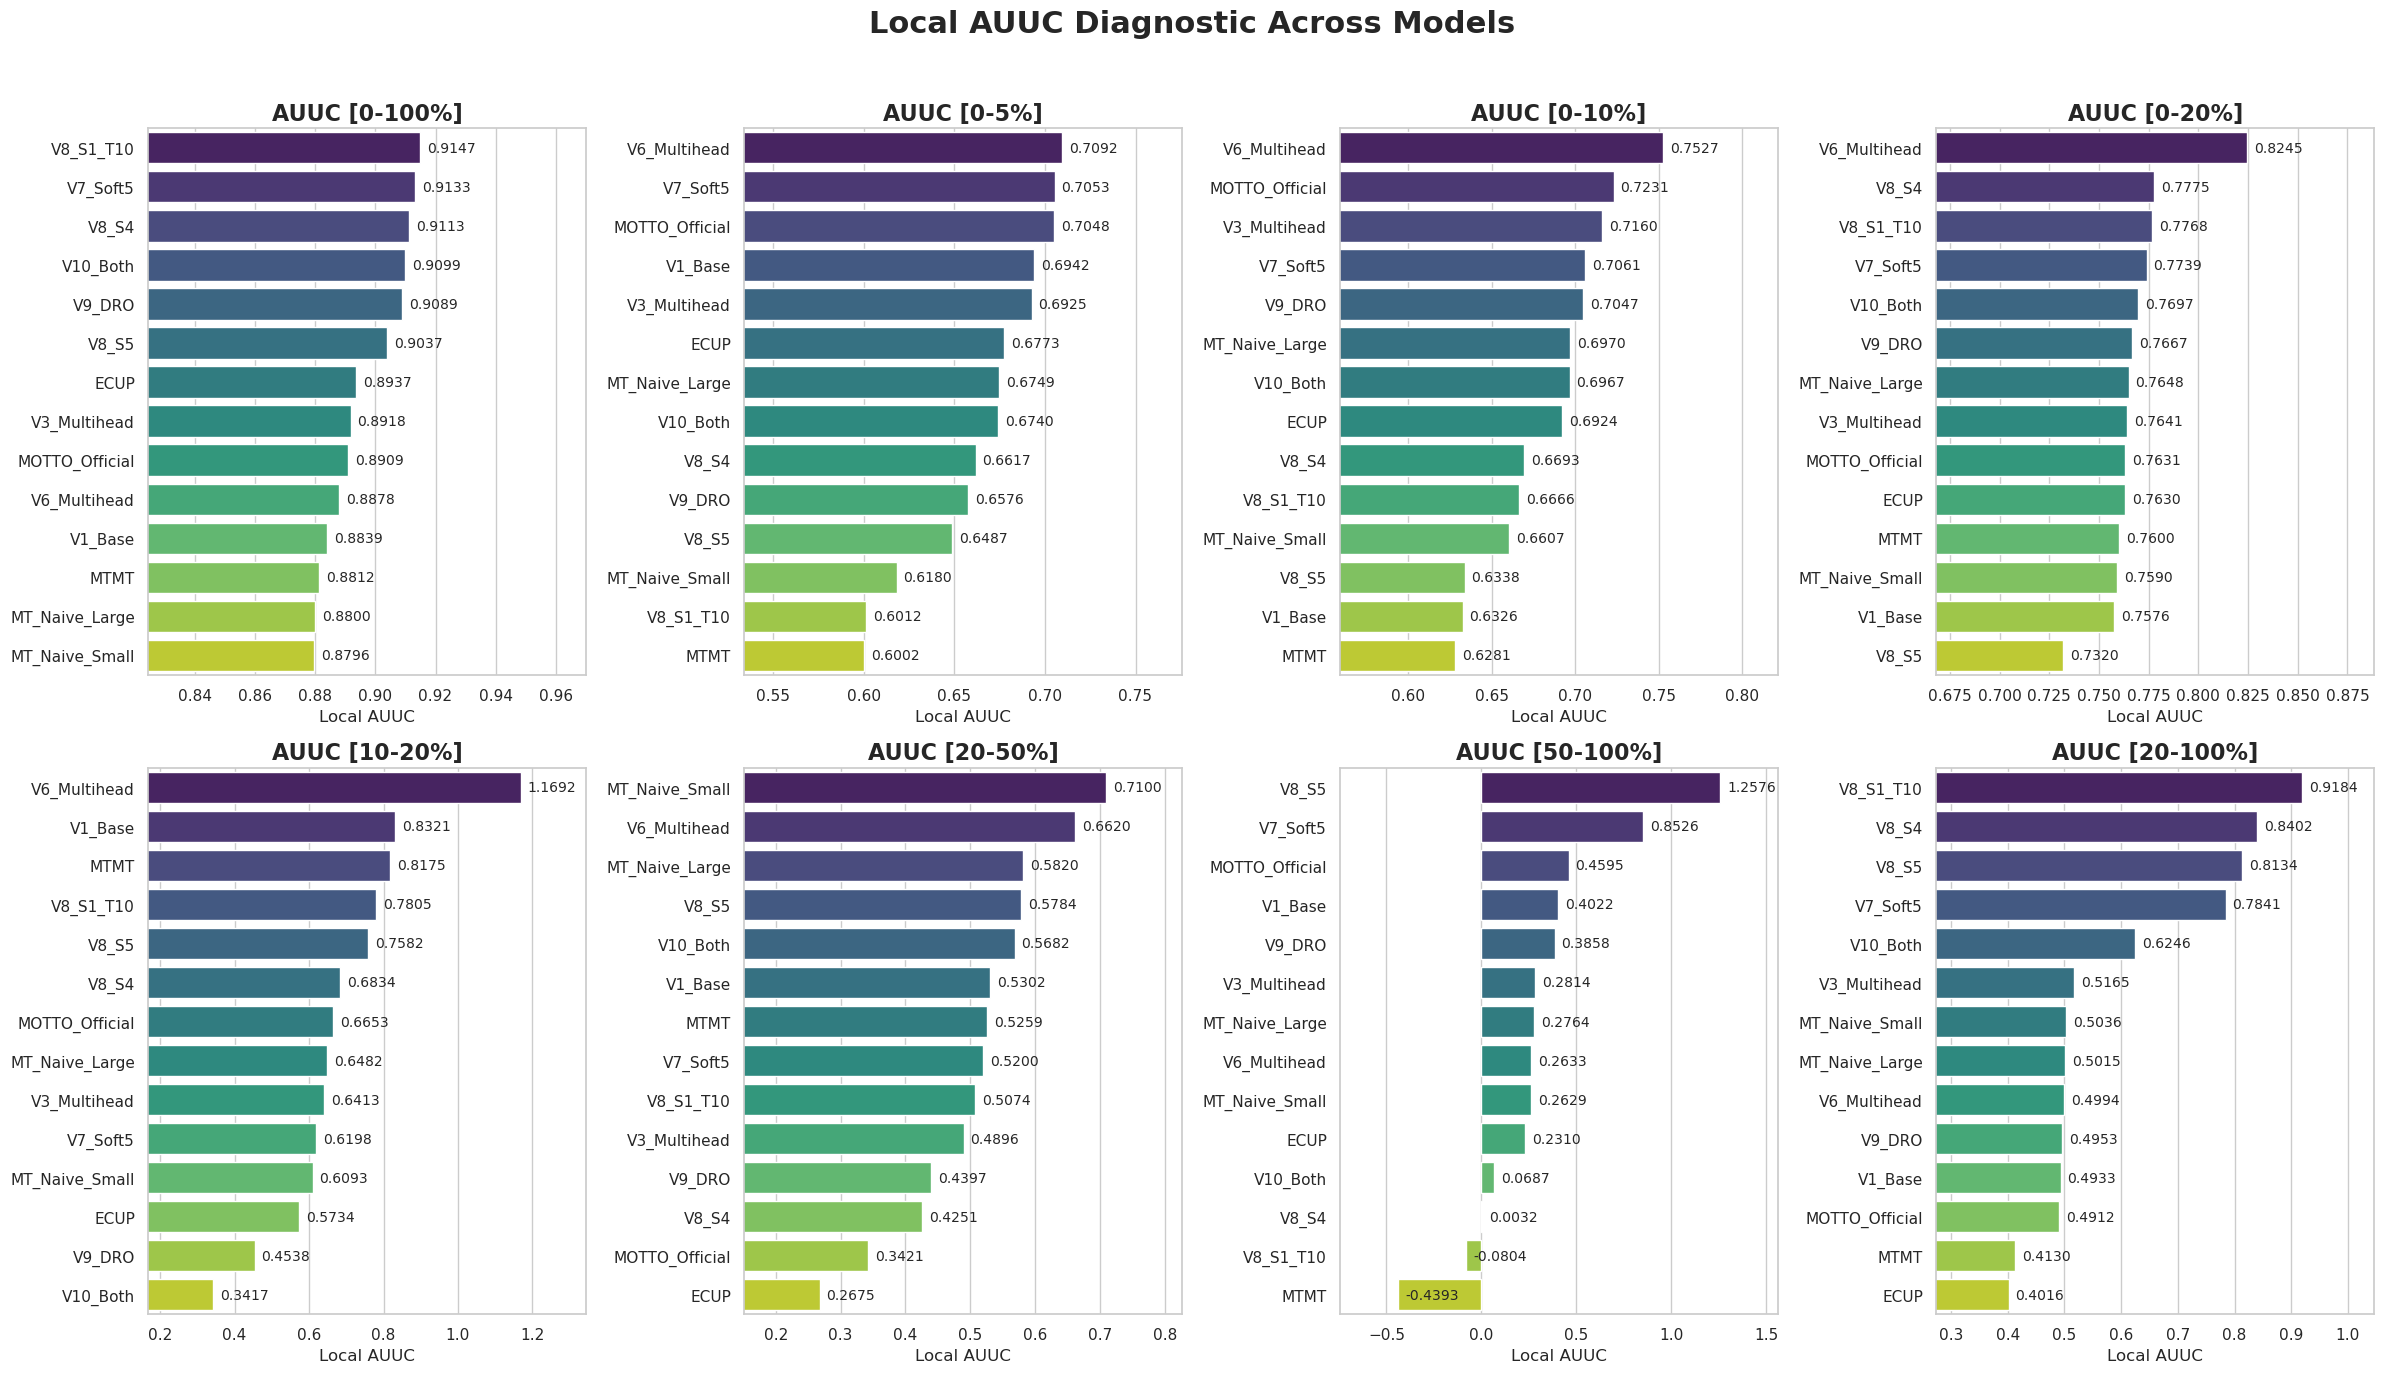

In [6]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 初始化设置与路径管理
# ==========================================
OUTPUT_DIR = "0414_analyze"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"

# 收录你提到的所有 baseline 和 multitask 最新模型
MODELS_TO_EVALUATE = {
    "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", # 请根据实际子文件夹结构调整
    "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv", # 请根据实际子文件夹结构调整,
    "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    'V6_Multihead':f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    "V8_S4": f"{BASE_DIR}TARNET/y_v8_s4/**/test_dist.csv",
    "V8_S5": f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv",
    "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# ==========================================
# 2. 核心算子：局部 AUUC 与 Lift 计算
# ==========================================
def compute_local_auuc(y_s, t_s):
    if len(y_s) < 2: return 0.0
    n_t = np.cumsum(t_s == 1)
    n_c = np.cumsum(t_s == 0)
    y_t = np.cumsum(y_s * (t_s == 1))
    y_c = np.cumsum(y_s * (t_s == 0))
    
    n_t_safe = np.where(n_t == 0, 1e-6, n_t)
    n_c_safe = np.where(n_c == 0, 1e-6, n_c)
    
    with np.errstate(invalid='ignore', divide='ignore'):
        curve = (y_t / n_t_safe - y_c / n_c_safe) * (n_t + n_c)
    curve = np.nan_to_num(curve)
    
    # 绝对值归一化，防止尾部负数导致曲线翻转
    endpoint = curve[-1]
    if abs(endpoint) > 1e-10:
        curve = curve / abs(endpoint)
        
    x_axis = np.arange(1, len(y_s) + 1) / len(y_s)
    return float(np.trapz(curve, x=x_axis))

def get_lift(y_true_sorted, t_sorted, k_pct):
    idx = int(len(y_true_sorted) * k_pct / 100.0)
    if idx == 0: return 0.0
    
    y_s = y_true_sorted[:idx]
    t_s = t_sorted[:idx]
    
    cr_t = np.sum(y_s[t_s == 1]) / (np.sum(t_s == 1) + 1e-9)
    cr_c = np.sum(y_s[t_s == 0]) / (np.sum(t_s == 0) + 1e-9)
    return float(cr_t - cr_c)

def get_slice_auuc(y_true_sorted, t_sorted, start_pct, end_pct):
    n = len(y_true_sorted)
    s_idx = int(n * start_pct / 100.0)
    e_idx = int(n * end_pct / 100.0)
    return compute_local_auuc(y_true_sorted[s_idx:e_idx], t_sorted[s_idx:e_idx])

# ==========================================
# 3. 数据扫描与指标提取
# ==========================================
print(f"🚀 正在扫描文件并计算各维度的 Lift 与 Local AUUC...")
results = []

for name, pattern in MODELS_TO_EVALUATE.items():
    files = glob.glob(pattern, recursive=True)
    if not files: 
        print(f"⚠️ 找不到模型: {name} (匹配路径: {pattern})")
        continue
        
    try:
        df = pd.read_csv(files[0])
        # 全局强制按模型自己的 uplift 预测降序！
        df = df.sort_values(by='uplift_pred', ascending=False).reset_index(drop=True)
        y_t = df['y_true'].values
        t_t = df['t'].values
        
        row = {
            "Model": name,
            "Lift@5": get_lift(y_t, t_t, 5),
            "Lift@10": get_lift(y_t, t_t, 10),
            "Lift@20": get_lift(y_t, t_t, 20),
            "AUUC [0-100%]": get_slice_auuc(y_t, t_t, 0, 100),
            "AUUC [0-5%]": get_slice_auuc(y_t, t_t, 0, 5),
            "AUUC [0-10%]": get_slice_auuc(y_t, t_t, 0, 10),
            "AUUC [10-20%]": get_slice_auuc(y_t, t_t, 10, 20),
            "AUUC [0-20%]": get_slice_auuc(y_t, t_t, 0, 20),
            "AUUC [20-50%]": get_slice_auuc(y_t, t_t, 20, 50),
            "AUUC [50-100%]": get_slice_auuc(y_t, t_t, 50, 100),
            "AUUC [20-100%]": get_slice_auuc(y_t, t_t, 20, 100)
        }
        results.append(row)
    except Exception as e:
        print(f"❌ 读取 {name} 失败: {e}")

df_res = pd.DataFrame(results)

# 打印并落盘表单
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n" + "="*140)
print("📊 第一步：各区间 Lift 与 Local AUUC 大满贯全景表")
print("="*140)
print(df_res.to_string(index=False))
print("="*140)

csv_path = os.path.join(OUTPUT_DIR, "step1_metrics_full.csv")
df_res.to_csv(csv_path, index=False)
print(f"✅ 全景表已保存至: {csv_path}")


# ==========================================
# 4. 可视化：AUUC 多维对比图 (你要的画图)
# ==========================================
print("\n🎨 正在绘制 AUUC 切片对比图...")

# 我们把这 7 个 AUUC 切片分为两组画图：头部聚焦区 vs 腰尾深水区
auuc_cols_head = ['AUUC [0-100%]', "AUUC [0-5%]", "AUUC [0-10%]", "AUUC [0-20%]"]
auuc_cols_tail = ["AUUC [10-20%]", "AUUC [20-50%]", "AUUC [50-100%]", "AUUC [20-100%]"]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 4, figsize=(24, 14))
fig.suptitle("Local AUUC Diagnostic Across Models", fontsize=22, fontweight='bold', y=0.98)

# 铺平 axes 方便遍历
axes_flat = axes.flatten()
all_auuc_cols = auuc_cols_head + auuc_cols_tail

for i, col in enumerate(all_auuc_cols):
    ax = axes_flat[i]
    # 对当前指标排个序，画出来更直观
    plot_data = df_res[["Model", col]].sort_values(by=col, ascending=False)
    
    sns.barplot(x=col, y="Model", data=plot_data, ax=ax, palette="viridis")
    ax.set_title(col, fontsize=16, fontweight='bold')
    ax.set_xlabel("Local AUUC", fontsize=12)
    ax.set_ylabel("")
    
    # 动态微调 X 轴以放大差异
    min_val, max_val = plot_data[col].min(), plot_data[col].max()
    margin = (max_val - min_val) * 0.15 + 0.05
    ax.set_xlim(min_val - margin, max_val + margin)
    
    # 把具体数值打在柱子上
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.4f}', (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

# 隐藏最后一个空着的 subplot (7个指标，8个格子)
# axes_flat[-1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plot_path = os.path.join(OUTPUT_DIR, "step1_auuc_comparison.png")
plt.savefig(plot_path, dpi=300)
print(f"✅ AUUC 切片对比图已生成: {plot_path}")

# 1.5 head uplift

✅ 终极散点图生成完毕：0414_analyze_internal/Top5_Causal_Frontier_Scatter.png


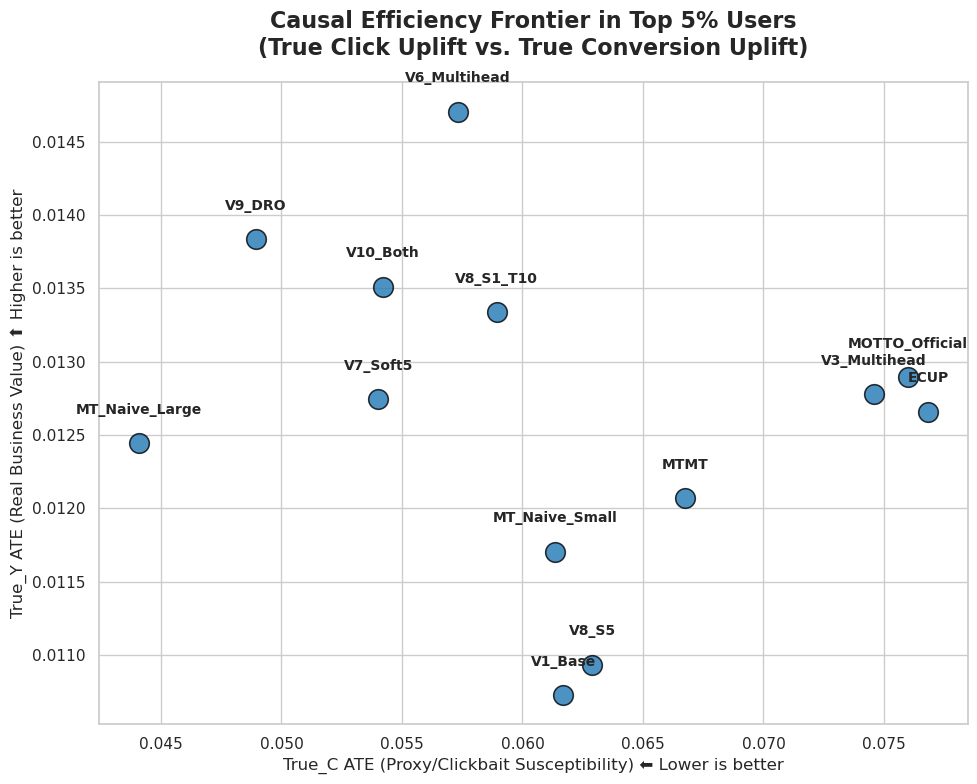

In [14]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取你刚才存下来的各个模型的内部解剖单
INPUT_DIR = "0414_analyze_internal"
csv_files = glob.glob(os.path.join(INPUT_DIR, "*_internal_anatomy.csv"))

results = []
for file in csv_files:
    model_name = os.path.basename(file).replace("_internal_anatomy.csv", "")
    df = pd.read_csv(file)
    
    # 我们只死死盯住 0-5% 这个最头部的区间
    top_5_row = df[df["Slice (%)"] == "0-5"].iloc[0]
    
    results.append({
        "Model": model_name,
        "True_C (Click Cost)": top_5_row["True_C (ATE)"],
        "True_Y (Conversion Gain)": top_5_row["True_Y (ATE)"]
    })

df_plot = pd.DataFrame(results)

# 开始画图
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# 画散点
scatter = sns.scatterplot(
    data=df_plot, 
    x="True_C (Click Cost)", 
    y="True_Y (Conversion Gain)", 
    s=200, # 点的大小
    color="#1f77b4", 
    edgecolor="black", 
    alpha=0.8
)

# 标上模型名字
for i in range(df_plot.shape[0]):
    plt.text(
        df_plot["True_C (Click Cost)"].iloc[i], 
        df_plot["True_Y (Conversion Gain)"].iloc[i] + 0.0002, # 稍微往上偏一点防止挡住点
        df_plot["Model"].iloc[i], 
        fontsize=10, 
        fontweight='bold',
        ha='center'
    )

# # 标出“因果解耦方向”的箭头
# plt.annotate(
#     "Ideal Decoupling Zone\n(High Conv, Low Click)", 
#     xy=(df_plot["True_C (Click Cost)"].min(), df_plot["True_Y (Conversion Gain)"].max()), 
#     xytext=(df_plot["True_C (Click Cost)"].max() - 0.005, df_plot["True_Y (Conversion Gain)"].min() + 0.001),
#     arrowprops=dict(facecolor='red', shrink=0.05, alpha=0.5, width=3),o
#     fontsize=12,
#     color='red',
#     fontweight='bold'
# )

plt.title("Causal Efficiency Frontier in Top 5% Users\n(True Click Uplift vs. True Conversion Uplift)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("True_C ATE (Proxy/Clickbait Susceptibility) ⬅️ Lower is better", fontsize=12)
plt.ylabel("True_Y ATE (Real Business Value) ⬆️ Higher is better", fontsize=12)

plt.tight_layout()
out_path = os.path.join(INPUT_DIR, "Top5_Causal_Frontier_Scatter.png")
plt.savefig(out_path, dpi=300)
print(f"✅ 终极散点图生成完毕：{out_path}")

inter_analyze

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 核心路径与配置
# ==========================================
OUTPUT_DIR = "0414_analyze_swapping_mt"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"
C_PRIOR_PATH = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv"
V1_BASE_PATH = f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv"

# 待测试的进阶模型（攻擂者）
ADV_MODELS = {
    # "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    # "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    # "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    # "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    'V8_S5': f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv", 
    # "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    # "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# 分析区间 (百分比)
BINS = [
    (0, 5), (5, 10), (10, 15), 
    (15, 20), (20, 30), (30,40),(40,50),(50,65),(65,80),(80,100)
]

# ==========================================
# 2. 数据基建：加载底座，确保行级绝对对齐
# ==========================================
print("📥 正在初始化统一宇宙 (对齐 V1 与 真实大盘)...")
v1_file = glob.glob(V1_BASE_PATH, recursive=True)[0]
c_file = glob.glob(C_PRIOR_PATH, recursive=True)[0]

df_v1 = pd.read_csv(v1_file)
df_c = pd.read_csv(c_file)

# 建立全局底表 (切记不要 sort_values 和 reset_index，保持原始行号)
master_df = pd.DataFrame({
    't': df_v1['t'],
    'y_true': df_v1['y_true'],
    'c_true': df_c['c_true'], # 强行以 C 模型文件里的 c_true 为准
    'v1_y_pred': df_v1['uplift_pred'],
    'indep_c_pred': df_c['y1_prob'] - df_c['y0_prob']
})

# 计算 V1 的全局排位 (0.0 是第一名，1.0 是最后一名)
master_df['v1_rank'] = master_df['v1_y_pred'].rank(pct=True, ascending=False)

# ==========================================
# 3. 核心算子
# ==========================================
def get_ate_stats(indices, prefix):
    if len(indices) == 0:
        return {f'{prefix}_Y_True': 0.0, f'{prefix}_C_True': 0.0, f'{prefix}_Pred_C': 0.0}
        
    group = master_df.loc[indices]
    t1, t0 = group[group['t'] == 1], group[group['t'] == 0]
    
    y_ate = (t1['y_true'].mean() if len(t1) > 0 else 0) - (t0['y_true'].mean() if len(t0) > 0 else 0)
    c_ate = (t1['c_true'].mean() if len(t1) > 0 else 0) - (t0['c_true'].mean() if len(t0) > 0 else 0)
    pred_c_avg = group['adv_c_pred'].mean() # 模型对这群人的 C 预期
    
    return {
        f'{prefix}_Y_True': y_ate,
        f'{prefix}_C_True': c_ate,
        f'{prefix}_Pred_C': pred_c_avg
    }

def analyze_bin_swapping(adv_name, start_pct, end_pct):
    # 找到在这个段位里的人群 (注意转换成 0~1 的比例)
    s_val, e_val = start_pct / 100.0, end_pct / 100.0
    
    v1_set = set(master_df[(master_df['v1_rank'] >= s_val) & (master_df['v1_rank'] < e_val)].index)
    adv_set = set(master_df[(master_df['adv_rank'] >= s_val) & (master_df['adv_rank'] < e_val)].index)
    
    # 核心：找分歧！
    adv_promoted = list(adv_set - v1_set)  # 进阶模型提拔的人
    v1_retained = list(v1_set - adv_set)   # V1 死守的人
    
    stats = {
        'Bin (%)': f"{start_pct}-{end_pct}",
        'Swapped_Size': len(adv_promoted)
    }
    stats.update(get_ate_stats(adv_promoted, 'Adv_Promoted'))
    stats.update(get_ate_stats(v1_retained, 'V1_Retained'))
    
    # 算净利润
    stats['Net_Y_Profit'] = stats['Adv_Promoted_Y_True'] - stats['V1_Retained_Y_True']
    stats['Net_C_Profit'] = stats['Adv_Promoted_C_True'] - stats['V1_Retained_C_True']
    
    return stats

# ==========================================
# 4. 绘图引擎 (改良自你的代码)
# ==========================================
def plot_swapping_analysis(summary_df, adv_name):
    """
    重构后的并排柱状图 PK：
    Top Subplot: 真实转化 (True Y) 的直接对抗
    Bottom Subplot: 真实点击 (True C) 的代价对比
    """
    labels = summary_df['Bin (%)'].tolist()
    x = np.arange(len(labels))
    width = 0.35  # 柱子宽度
    
    # 提取数据
    y_new = summary_df['Adv_Promoted_Y_True'].tolist()
    y_v1 = summary_df['V1_Retained_Y_True'].tolist()
    c_new = summary_df['Adv_Promoted_C_True'].tolist()
    c_v1 = summary_df['V1_Retained_C_True'].tolist()

    # 设置样式
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))
    plt.subplots_adjust(hspace=0.3)

    # --- 第一局：True Y Uplift (越往上越牛逼，负值代表发券起反作用) ---
    # 新模型用深蓝色，V1 用代表警告或对照的浅灰色/红色
    rects1 = ax1.bar(x - width/2, y_new, width, label=f'New Model ({adv_name})', color='#1f77b4', edgecolor='black')
    rects2 = ax1.bar(x + width/2, y_v1, width, label='Baseline (V1)', color='#e0e0e0', edgecolor='black')
    
    ax1.set_title(f'Mechanism PK: Conversion Power (True Y Uplift)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('True Y ATE', fontsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.axhline(0, color='black', linewidth=1.2) # 0基准线
    ax1.legend()

    # 在柱子上加数值标注 (如果数值太小可以不加，这里加上方便看细节)
    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3 if height > 0 else -12),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    autolabel(rects1, ax1)
    autolabel(rects2, ax1)

    # --- 第二局：True C Uplift (衡量“点击代价”，如果很高但Y很低，就是羊毛党) ---
    # 点击代价用橙色系或紫色系
    rects3 = ax2.bar(x - width/2, c_new, width, label=f'New Model ({adv_name})', color='#9467bd', edgecolor='black')
    rects4 = ax2.bar(x + width/2, c_v1, width, label='Baseline (V1)', color='#ffbb78', edgecolor='black')
    
    ax2.set_title(f'Mechanism PK: Click Cost (True C Uplift)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('True C ATE', fontsize=13)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.axhline(0, color='black', linewidth=1.2)
    ax2.legend()
    
    autolabel(rects3, ax2)
    autolabel(rects4, ax2)

    plt.suptitle(f"Population Swapping Analysis: {adv_name} vs. V1_Base", fontsize=20, fontweight='bold', y=0.98)
    
    # 保存
    plot_path = os.path.join(OUTPUT_DIR, f"Refined_PK_{adv_name}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Refined PK Chart saved: {plot_path}")

# ==========================================
# 5. 执行循环大阅兵
# ==========================================
for adv_name, adv_pattern in ADV_MODELS.items():
    adv_files = glob.glob(adv_pattern, recursive=True)
    if not adv_files: continue
        
    print(f"\n⚔️ 正在解剖换血对局: {adv_name} VS V1_Base")
    df_adv = pd.read_csv(adv_files[0])
    
    # 注入 Adv 模型的预测
    master_df['adv_y_pred'] = df_adv['uplift_pred']
    if 'c_uplift_pred' in df_adv.columns:
        master_df['adv_c_pred'] = df_adv['c_uplift_pred'] # MTL 自己测的
    else:
        master_df['adv_c_pred'] = master_df['indep_c_pred'] # V7/V8 读先验的
        
    master_df['adv_rank'] = master_df['adv_y_pred'].rank(pct=True, ascending=False)
    
    # 计算统计
    summary_results = []
    for start, end in BINS:
        summary_results.append(analyze_bin_swapping(adv_name, start, end))
        
    df_summary = pd.DataFrame(summary_results)
    
    # 打印极简报表 (隐藏了一些过于繁琐的列，只留核心战况)
    display_cols = [
        'Bin (%)', 'Swapped_Size', 
        'Adv_Promoted_Y_True', 'V1_Retained_Y_True', 'Net_Y_Profit',
        'Adv_Promoted_C_True', 'V1_Retained_C_True'
    ]
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("-" * 120)
    print(df_summary[display_cols].to_string(index=False))
    print("-" * 120)
    
    # 存全量 CSV
    csv_path = os.path.join(OUTPUT_DIR, f"Swap_Data_{adv_name}.csv")
    df_summary.to_csv(csv_path, index=False)
    
    # 画图
    plot_swapping_analysis(df_summary, adv_name)

print("\n🎉 全部换血对账单处理完毕！图表和数据均在 0414_analyze_swapping/ 下。")

📥 正在初始化统一宇宙 (对齐 V1 与 真实大盘)...

⚔️ 正在解剖换血对局: MT_Naive_Small VS V1_Base
------------------------------------------------------------------------------------------------------------------------
Bin (%)  Swapped_Size  Adv_Promoted_Y_True  V1_Retained_Y_True  Net_Y_Profit  Adv_Promoted_C_True  V1_Retained_C_True
    0-5          5680              0.01708             0.00453       0.01255              0.04767             0.04768
   5-10         23825              0.00140             0.00683      -0.00542              0.02734             0.03208
  10-15         54518              0.00038             0.00056      -0.00018              0.00927             0.01121
  15-20         59991              0.00098             0.00020       0.00079              0.00935             0.00578
  20-30        130637              0.00040             0.00011       0.00029              0.00611             0.00395
  30-40        139635              0.00013             0.00019      -0.00006              0.00183    

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 核心路径与配置
# ==========================================
OUTPUT_DIR = "0414_analyze_swapping_single"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"
C_PRIOR_PATH = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv"
V1_BASE_PATH = f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv"

# 待测试的进阶模型（攻擂者）
ADV_MODELS = {
    # "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    # "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    # "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    # "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    # "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    # "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    'V8_S5': f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv", 
    "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# 分析区间 (百分比)
BINS = [
    (0, 5), (5, 10), (10, 15), 
    (15, 20), (20, 30), (30,40),(40,50),(50,65),(65,80),(80,100)
]

# ==========================================
# 2. 数据基建：加载底座，确保行级绝对对齐
# ==========================================
print("📥 正在初始化统一宇宙 (对齐 V1 与 真实大盘)...")
v1_file = glob.glob(V1_BASE_PATH, recursive=True)[0]
c_file = glob.glob(C_PRIOR_PATH, recursive=True)[0]

df_v1 = pd.read_csv(v1_file)
df_c = pd.read_csv(c_file)

# 建立全局底表 (切记不要 sort_values 和 reset_index，保持原始行号)
master_df = pd.DataFrame({
    't': df_v1['t'],
    'y_true': df_v1['y_true'],
    'c_true': df_c['c_true'], # 强行以 C 模型文件里的 c_true 为准
    'v1_y_pred': df_v1['uplift_pred'],
    'indep_c_pred': df_c['y1_prob'] - df_c['y0_prob']
})

# 计算 V1 的全局排位 (0.0 是第一名，1.0 是最后一名)
master_df['v1_rank'] = master_df['v1_y_pred'].rank(pct=True, ascending=False)

# ==========================================
# 3. 核心算子
# ==========================================
def get_ate_stats(indices, prefix):
    if len(indices) == 0:
        return {f'{prefix}_Y_True': 0.0, f'{prefix}_C_True': 0.0, f'{prefix}_Pred_C': 0.0}
        
    group = master_df.loc[indices]
    t1, t0 = group[group['t'] == 1], group[group['t'] == 0]
    
    y_ate = (t1['y_true'].mean() if len(t1) > 0 else 0) - (t0['y_true'].mean() if len(t0) > 0 else 0)
    c_ate = (t1['c_true'].mean() if len(t1) > 0 else 0) - (t0['c_true'].mean() if len(t0) > 0 else 0)
    pred_c_avg = group['adv_c_pred'].mean() # 模型对这群人的 C 预期
    
    return {
        f'{prefix}_Y_True': y_ate,
        f'{prefix}_C_True': c_ate,
        f'{prefix}_Pred_C': pred_c_avg
    }

def analyze_bin_swapping(adv_name, start_pct, end_pct):
    # 找到在这个段位里的人群 (注意转换成 0~1 的比例)
    s_val, e_val = start_pct / 100.0, end_pct / 100.0
    
    v1_set = set(master_df[(master_df['v1_rank'] >= s_val) & (master_df['v1_rank'] < e_val)].index)
    adv_set = set(master_df[(master_df['adv_rank'] >= s_val) & (master_df['adv_rank'] < e_val)].index)
    
    # 核心：找分歧！
    adv_promoted = list(adv_set - v1_set)  # 进阶模型提拔的人
    v1_retained = list(v1_set - adv_set)   # V1 死守的人
    
    stats = {
        'Bin (%)': f"{start_pct}-{end_pct}",
        'Swapped_Size': len(adv_promoted)
    }
    stats.update(get_ate_stats(adv_promoted, 'Adv_Promoted'))
    stats.update(get_ate_stats(v1_retained, 'V1_Retained'))
    
    # 算净利润
    stats['Net_Y_Profit'] = stats['Adv_Promoted_Y_True'] - stats['V1_Retained_Y_True']
    stats['Net_C_Profit'] = stats['Adv_Promoted_C_True'] - stats['V1_Retained_C_True']
    
    return stats

# ==========================================
# 4. 绘图引擎 (改良自你的代码)
# ==========================================
def plot_swapping_analysis(summary_df, adv_name):
    """
    重构后的并排柱状图 PK：
    Top Subplot: 真实转化 (True Y) 的直接对抗
    Bottom Subplot: 真实点击 (True C) 的代价对比
    """
    labels = summary_df['Bin (%)'].tolist()
    x = np.arange(len(labels))
    width = 0.35  # 柱子宽度
    
    # 提取数据
    y_new = summary_df['Adv_Promoted_Y_True'].tolist()
    y_v1 = summary_df['V1_Retained_Y_True'].tolist()
    c_new = summary_df['Adv_Promoted_C_True'].tolist()
    c_v1 = summary_df['V1_Retained_C_True'].tolist()

    # 设置样式
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))
    plt.subplots_adjust(hspace=0.3)

    # --- 第一局：True Y Uplift (越往上越牛逼，负值代表发券起反作用) ---
    # 新模型用深蓝色，V1 用代表警告或对照的浅灰色/红色
    rects1 = ax1.bar(x - width/2, y_new, width, label=f'New Model ({adv_name})', color='#1f77b4', edgecolor='black')
    rects2 = ax1.bar(x + width/2, y_v1, width, label='Baseline (V1)', color='#e0e0e0', edgecolor='black')
    
    ax1.set_title(f'Mechanism PK: Conversion Power (True Y Uplift)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('True Y ATE', fontsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.axhline(0, color='black', linewidth=1.2) # 0基准线
    ax1.legend()

    # 在柱子上加数值标注 (如果数值太小可以不加，这里加上方便看细节)
    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3 if height > 0 else -12),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    autolabel(rects1, ax1)
    autolabel(rects2, ax1)

    # --- 第二局：True C Uplift (衡量“点击代价”，如果很高但Y很低，就是羊毛党) ---
    # 点击代价用橙色系或紫色系
    rects3 = ax2.bar(x - width/2, c_new, width, label=f'New Model ({adv_name})', color='#9467bd', edgecolor='black')
    rects4 = ax2.bar(x + width/2, c_v1, width, label='Baseline (V1)', color='#ffbb78', edgecolor='black')
    
    ax2.set_title(f'Mechanism PK: Click Cost (True C Uplift)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('True C ATE', fontsize=13)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.axhline(0, color='black', linewidth=1.2)
    ax2.legend()
    
    autolabel(rects3, ax2)
    autolabel(rects4, ax2)

    plt.suptitle(f"Population Swapping Analysis: {adv_name} vs. V1_Base", fontsize=20, fontweight='bold', y=0.98)
    
    # 保存
    plot_path = os.path.join(OUTPUT_DIR, f"Refined_PK_{adv_name}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Refined PK Chart saved: {plot_path}")

# ==========================================
# 5. 执行循环大阅兵
# ==========================================
for adv_name, adv_pattern in ADV_MODELS.items():
    adv_files = glob.glob(adv_pattern, recursive=True)
    if not adv_files: continue
        
    print(f"\n⚔️ 正在解剖换血对局: {adv_name} VS V1_Base")
    df_adv = pd.read_csv(adv_files[0])
    
    # 注入 Adv 模型的预测
    master_df['adv_y_pred'] = df_adv['uplift_pred']
    if 'c_uplift_pred' in df_adv.columns:
        master_df['adv_c_pred'] = df_adv['c_uplift_pred'] # MTL 自己测的
    else:
        master_df['adv_c_pred'] = master_df['indep_c_pred'] # V7/V8 读先验的
        
    master_df['adv_rank'] = master_df['adv_y_pred'].rank(pct=True, ascending=False)
    
    # 计算统计
    summary_results = []
    for start, end in BINS:
        summary_results.append(analyze_bin_swapping(adv_name, start, end))
        
    df_summary = pd.DataFrame(summary_results)
    
    # 打印极简报表 (隐藏了一些过于繁琐的列，只留核心战况)
    display_cols = [
        'Bin (%)', 'Swapped_Size', 
        'Adv_Promoted_Y_True', 'V1_Retained_Y_True', 'Net_Y_Profit',
        'Adv_Promoted_C_True', 'V1_Retained_C_True'
    ]
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("-" * 120)
    print(df_summary[display_cols].to_string(index=False))
    print("-" * 120)
    
    # 存全量 CSV
    csv_path = os.path.join(OUTPUT_DIR, f"Swap_Data_{adv_name}.csv")
    df_summary.to_csv(csv_path, index=False)
    
    # 画图
    plot_swapping_analysis(df_summary, adv_name)

print("\n🎉 全部换血对账单处理完毕！图表和数据均在 0414_analyze_swapping/ 下。")

📥 正在初始化统一宇宙 (对齐 V1 与 真实大盘)...

⚔️ 正在解剖换血对局: V3_Multihead VS V1_Base
------------------------------------------------------------------------------------------------------------------------
Bin (%)  Swapped_Size  Adv_Promoted_Y_True  V1_Retained_Y_True  Net_Y_Profit  Adv_Promoted_C_True  V1_Retained_C_True
    0-5         23115              0.01124             0.00082       0.01042              0.05680             0.00685
   5-10         46699              0.00050             0.00619      -0.00568              0.01213             0.02801
  10-15         52132              0.00127             0.00130      -0.00003              0.01191             0.01323
  15-20         59735              0.00047             0.00018       0.00028              0.00756             0.00634
  20-30        129194              0.00016             0.00010       0.00006              0.00391             0.00433
  30-40        139723              0.00002             0.00019      -0.00017              0.00101      

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 核心路径与配置
# ==========================================
OUTPUT_DIR = "0414_analyze_swapping_v8_watch_tail"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"
C_PRIOR_PATH = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv"
V1_BASE_PATH = f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv"

# 待测试的进阶模型（攻擂者）
ADV_MODELS = {
    # "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    # "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    # "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    # "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    # "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    # "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    # "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    # "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    # "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S1_T10": f"{BASE_DIR}TARNET/y_v8_s1_t10/**/test_dist.csv",
    # 'V8_S5': f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv", 
    # "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    # "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# 分析区间 (百分比)
BINS = [
    (0, 5), (5, 10), (10, 15), 
    (15, 20), (20, 30), (30,40),(40,50),(50,65),(65,80),(80,100)
]

# ==========================================
# 2. 数据基建：加载底座，确保行级绝对对齐
# ==========================================
print("📥 正在初始化统一宇宙 (对齐 V8s5 与 真实大盘)...")
v1_file = glob.glob(V1_BASE_PATH, recursive=True)[0]
c_file = glob.glob(C_PRIOR_PATH, recursive=True)[0]

df_v1 = pd.read_csv(v1_file)
df_c = pd.read_csv(c_file)

# 建立全局底表 (切记不要 sort_values 和 reset_index，保持原始行号)
master_df = pd.DataFrame({
    't': df_v1['t'],
    'y_true': df_v1['y_true'],
    'c_true': df_c['c_true'], # 强行以 C 模型文件里的 c_true 为准
    'v1_y_pred': df_v1['uplift_pred'],
    'indep_c_pred': df_c['y1_prob'] - df_c['y0_prob']
})

# 计算 V1 的全局排位 (0.0 是第一名，1.0 是最后一名)
master_df['v1_rank'] = master_df['v1_y_pred'].rank(pct=True, ascending=False)

# ==========================================
# 3. 核心算子
# ==========================================
def get_ate_stats(indices, prefix):
    if len(indices) == 0:
        return {f'{prefix}_Y_True': 0.0, f'{prefix}_C_True': 0.0, f'{prefix}_Pred_C': 0.0}
        
    group = master_df.loc[indices]
    t1, t0 = group[group['t'] == 1], group[group['t'] == 0]
    
    y_ate = (t1['y_true'].mean() if len(t1) > 0 else 0) - (t0['y_true'].mean() if len(t0) > 0 else 0)
    c_ate = (t1['c_true'].mean() if len(t1) > 0 else 0) - (t0['c_true'].mean() if len(t0) > 0 else 0)
    pred_c_avg = group['adv_c_pred'].mean() # 模型对这群人的 C 预期
    
    return {
        f'{prefix}_Y_True': y_ate,
        f'{prefix}_C_True': c_ate,
        f'{prefix}_Pred_C': pred_c_avg
    }

def analyze_bin_swapping(adv_name, start_pct, end_pct):
    # 找到在这个段位里的人群 (注意转换成 0~1 的比例)
    s_val, e_val = start_pct / 100.0, end_pct / 100.0
    
    v1_set = set(master_df[(master_df['v1_rank'] >= s_val) & (master_df['v1_rank'] < e_val)].index)
    adv_set = set(master_df[(master_df['adv_rank'] >= s_val) & (master_df['adv_rank'] < e_val)].index)
    
    # 核心：找分歧！
    adv_promoted = list(adv_set - v1_set)  # 进阶模型提拔的人
    v1_retained = list(v1_set - adv_set)   # V1 死守的人
    
    stats = {
        'Bin (%)': f"{start_pct}-{end_pct}",
        'Swapped_Size': len(adv_promoted)
    }
    stats.update(get_ate_stats(adv_promoted, 'Adv_Promoted'))
    stats.update(get_ate_stats(v1_retained, 'V1_Retained'))
    
    # 算净利润
    stats['Net_Y_Profit'] = stats['Adv_Promoted_Y_True'] - stats['V1_Retained_Y_True']
    stats['Net_C_Profit'] = stats['Adv_Promoted_C_True'] - stats['V1_Retained_C_True']
    
    return stats

# ==========================================
# 4. 绘图引擎 (改良自你的代码)
# ==========================================
def plot_swapping_analysis(summary_df, adv_name):
    """
    重构后的并排柱状图 PK：
    Top Subplot: 真实转化 (True Y) 的直接对抗
    Bottom Subplot: 真实点击 (True C) 的代价对比
    """
    labels = summary_df['Bin (%)'].tolist()
    x = np.arange(len(labels))
    width = 0.35  # 柱子宽度
    
    # 提取数据
    y_new = summary_df['Adv_Promoted_Y_True'].tolist()
    y_v1 = summary_df['V1_Retained_Y_True'].tolist()
    c_new = summary_df['Adv_Promoted_C_True'].tolist()
    c_v1 = summary_df['V1_Retained_C_True'].tolist()

    # 设置样式
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))
    plt.subplots_adjust(hspace=0.3)

    # --- 第一局：True Y Uplift (越往上越牛逼，负值代表发券起反作用) ---
    # 新模型用深蓝色，V1 用代表警告或对照的浅灰色/红色
    rects1 = ax1.bar(x - width/2, y_new, width, label=f'New Model ({adv_name})', color='#1f77b4', edgecolor='black')
    rects2 = ax1.bar(x + width/2, y_v1, width, label='Baseline (V1)', color='#e0e0e0', edgecolor='black')
    
    ax1.set_title(f'Mechanism PK: Conversion Power (True Y Uplift)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('True Y ATE', fontsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.axhline(0, color='black', linewidth=1.2) # 0基准线
    ax1.legend()

    # 在柱子上加数值标注 (如果数值太小可以不加，这里加上方便看细节)
    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3 if height > 0 else -12),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    autolabel(rects1, ax1)
    autolabel(rects2, ax1)

    # --- 第二局：True C Uplift (衡量“点击代价”，如果很高但Y很低，就是羊毛党) ---
    # 点击代价用橙色系或紫色系
    rects3 = ax2.bar(x - width/2, c_new, width, label=f'New Model ({adv_name})', color='#9467bd', edgecolor='black')
    rects4 = ax2.bar(x + width/2, c_v1, width, label='Baseline (V8s5)', color='#ffbb78', edgecolor='black')
    
    ax2.set_title(f'Mechanism PK: Click Cost (True C Uplift)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('True C ATE', fontsize=13)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.axhline(0, color='black', linewidth=1.2)
    ax2.legend()
    
    autolabel(rects3, ax2)
    autolabel(rects4, ax2)

    plt.suptitle(f"Population Swapping Analysis: {adv_name} vs. V8_s5", fontsize=20, fontweight='bold', y=0.98)
    
    # 保存
    plot_path = os.path.join(OUTPUT_DIR, f"Refined_PK_{adv_name}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Refined PK Chart saved: {plot_path}")

# ==========================================
# 5. 执行循环大阅兵
# ==========================================
for adv_name, adv_pattern in ADV_MODELS.items():
    adv_files = glob.glob(adv_pattern, recursive=True)
    if not adv_files: continue
        
    print(f"\n⚔️ 正在解剖换血对局: {adv_name} VS V8_s5")
    df_adv = pd.read_csv(adv_files[0])
    
    # 注入 Adv 模型的预测
    master_df['adv_y_pred'] = df_adv['uplift_pred']
    if 'c_uplift_pred' in df_adv.columns:
        master_df['adv_c_pred'] = df_adv['c_uplift_pred'] # MTL 自己测的
    else:
        master_df['adv_c_pred'] = master_df['indep_c_pred'] # V7/V8 读先验的
        
    master_df['adv_rank'] = master_df['adv_y_pred'].rank(pct=True, ascending=False)
    
    # 计算统计
    summary_results = []
    for start, end in BINS:
        summary_results.append(analyze_bin_swapping(adv_name, start, end))
        
    df_summary = pd.DataFrame(summary_results)
    
    # 打印极简报表 (隐藏了一些过于繁琐的列，只留核心战况)
    display_cols = [
        'Bin (%)', 'Swapped_Size', 
        'Adv_Promoted_Y_True', 'V1_Retained_Y_True', 'Net_Y_Profit',
        'Adv_Promoted_C_True', 'V1_Retained_C_True'
    ]
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("-" * 120)
    print(df_summary[display_cols].to_string(index=False))
    print("-" * 120)
    
    # 存全量 CSV
    csv_path = os.path.join(OUTPUT_DIR, f"Swap_Data_{adv_name}.csv")
    df_summary.to_csv(csv_path, index=False)
    
    # 画图
    plot_swapping_analysis(df_summary, adv_name)

print("\n🎉 全部换血对账单处理完毕！图表和数据均在 0414_analyze_swapping/ 下。")

📥 正在初始化统一宇宙 (对齐 V8s5 与 真实大盘)...

⚔️ 正在解剖换血对局: V8_S1_T10 VS V8_s5
------------------------------------------------------------------------------------------------------------------------
Bin (%)  Swapped_Size  Adv_Promoted_Y_True  V1_Retained_Y_True  Net_Y_Profit  Adv_Promoted_C_True  V1_Retained_C_True
    0-5          8199              0.02348             0.00218       0.02130              0.02869             0.05267
   5-10         16233              0.00416             0.01067      -0.00651              0.04208             0.03136
  10-15         20527              0.00199             0.00550      -0.00351              0.03315             0.02847
  15-20         25296              0.00076             0.00122      -0.00046              0.01037             0.01927
  20-30        113102              0.00039             0.00011       0.00028              0.00341             0.00997
  30-40        112881              0.00012             0.00012      -0.00000              0.00226         

In [4]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 核心路径与配置
# ==========================================
OUTPUT_DIR = "0414_analyze_swapping_v8_watch_tail"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR = "/NAS/shith/uplift/results/criteo/train_y/"
C_PRIOR_PATH = "/NAS/shith/uplift/results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv"
V1_BASE_PATH = f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv"

# 待测试的进阶模型（攻擂者）
ADV_MODELS = {
    # "V1_Base": f"{BASE_DIR}TARNET/y_v1_base/**/test_dist.csv",
    # "MT_Naive_Small": f"{BASE_DIR}TARNET/y_v1_naive_mt_small_c_weight/**/test_dist.csv",
    # "MT_Naive_Large": f"{BASE_DIR}TARNET/y_v1_naive_mt_larger_c_weight/**/test_dist.csv",
    # "MOTTO_Official": f"{BASE_DIR}MOTTO/y_motto/motto_kdd25_official_20260409/**/test_dist.csv",
    # "MTMT": f"{BASE_DIR}MTMT/**/test_dist.csv", 
    # "ECUP": f"{BASE_DIR}ECUP/**/test_dist.csv",
    # "V3_Multihead": f"{BASE_DIR}TARNET/y_v3_moe/**/test_dist.csv",
    # "V6_Multihead": f"{BASE_DIR}TARNET/y_v6_res_moe/**/test_dist.csv", 
    # "V7_Soft5": f"{BASE_DIR}TARNET/y_v7_soft_top5/**/test_dist.csv",
    "V8_S4": f"{BASE_DIR}TARNET/y_v8_s4/**/test_dist.csv",
    # 'V8_S5': f"{BASE_DIR}TARNET/y_v8_s5/**/test_dist.csv", 
    # "V9_DRO": f"{BASE_DIR}TARNET/y_v9_dro_a_coarse/**/test_dist.csv",
    # "V10_Both": f"{BASE_DIR}TARNET/y_v10_conflict_both/**/test_dist.csv"
}

# 分析区间 (百分比)
BINS = [
    (0, 5), (5, 10), (10, 15), 
    (15, 20), (20, 30), (30,40),(40,50),(50,65),(65,80),(80,100)
]

# ==========================================
# 2. 数据基建：加载底座，确保行级绝对对齐
# ==========================================
print("📥 正在初始化统一宇宙 (对齐 V8s5 与 真实大盘)...")
v1_file = glob.glob(V1_BASE_PATH, recursive=True)[0]
c_file = glob.glob(C_PRIOR_PATH, recursive=True)[0]

df_v1 = pd.read_csv(v1_file)
df_c = pd.read_csv(c_file)

# 建立全局底表 (切记不要 sort_values 和 reset_index，保持原始行号)
master_df = pd.DataFrame({
    't': df_v1['t'],
    'y_true': df_v1['y_true'],
    'c_true': df_c['c_true'], # 强行以 C 模型文件里的 c_true 为准
    'v1_y_pred': df_v1['uplift_pred'],
    'indep_c_pred': df_c['y1_prob'] - df_c['y0_prob']
})

# 计算 V1 的全局排位 (0.0 是第一名，1.0 是最后一名)
master_df['v1_rank'] = master_df['v1_y_pred'].rank(pct=True, ascending=False)

# ==========================================
# 3. 核心算子
# ==========================================
def get_ate_stats(indices, prefix):
    if len(indices) == 0:
        return {f'{prefix}_Y_True': 0.0, f'{prefix}_C_True': 0.0, f'{prefix}_Pred_C': 0.0}
        
    group = master_df.loc[indices]
    t1, t0 = group[group['t'] == 1], group[group['t'] == 0]
    
    y_ate = (t1['y_true'].mean() if len(t1) > 0 else 0) - (t0['y_true'].mean() if len(t0) > 0 else 0)
    c_ate = (t1['c_true'].mean() if len(t1) > 0 else 0) - (t0['c_true'].mean() if len(t0) > 0 else 0)
    pred_c_avg = group['adv_c_pred'].mean() # 模型对这群人的 C 预期
    
    return {
        f'{prefix}_Y_True': y_ate,
        f'{prefix}_C_True': c_ate,
        f'{prefix}_Pred_C': pred_c_avg
    }

def analyze_bin_swapping(adv_name, start_pct, end_pct):
    # 找到在这个段位里的人群 (注意转换成 0~1 的比例)
    s_val, e_val = start_pct / 100.0, end_pct / 100.0
    
    v1_set = set(master_df[(master_df['v1_rank'] >= s_val) & (master_df['v1_rank'] < e_val)].index)
    adv_set = set(master_df[(master_df['adv_rank'] >= s_val) & (master_df['adv_rank'] < e_val)].index)
    
    # 核心：找分歧！
    adv_promoted = list(adv_set - v1_set)  # 进阶模型提拔的人
    v1_retained = list(v1_set - adv_set)   # V1 死守的人
    
    stats = {
        'Bin (%)': f"{start_pct}-{end_pct}",
        'Swapped_Size': len(adv_promoted)
    }
    stats.update(get_ate_stats(adv_promoted, 'Adv_Promoted'))
    stats.update(get_ate_stats(v1_retained, 'V1_Retained'))
    
    # 算净利润
    stats['Net_Y_Profit'] = stats['Adv_Promoted_Y_True'] - stats['V1_Retained_Y_True']
    stats['Net_C_Profit'] = stats['Adv_Promoted_C_True'] - stats['V1_Retained_C_True']
    
    return stats

# ==========================================
# 4. 绘图引擎 (改良自你的代码)
# ==========================================
def plot_swapping_analysis(summary_df, adv_name):
    """
    重构后的并排柱状图 PK：
    Top Subplot: 真实转化 (True Y) 的直接对抗
    Bottom Subplot: 真实点击 (True C) 的代价对比
    """
    labels = summary_df['Bin (%)'].tolist()
    x = np.arange(len(labels))
    width = 0.35  # 柱子宽度
    
    # 提取数据
    y_new = summary_df['Adv_Promoted_Y_True'].tolist()
    y_v1 = summary_df['V1_Retained_Y_True'].tolist()
    c_new = summary_df['Adv_Promoted_C_True'].tolist()
    c_v1 = summary_df['V1_Retained_C_True'].tolist()

    # 设置样式
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))
    plt.subplots_adjust(hspace=0.3)

    # --- 第一局：True Y Uplift (越往上越牛逼，负值代表发券起反作用) ---
    # 新模型用深蓝色，V1 用代表警告或对照的浅灰色/红色
    rects1 = ax1.bar(x - width/2, y_new, width, label=f'New Model ({adv_name})', color='#1f77b4', edgecolor='black')
    rects2 = ax1.bar(x + width/2, y_v1, width, label='Baseline (V1)', color='#e0e0e0', edgecolor='black')
    
    ax1.set_title(f'Mechanism PK: Conversion Power (True Y Uplift)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('True Y ATE', fontsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.axhline(0, color='black', linewidth=1.2) # 0基准线
    ax1.legend()

    # 在柱子上加数值标注 (如果数值太小可以不加，这里加上方便看细节)
    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3 if height > 0 else -12),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    autolabel(rects1, ax1)
    autolabel(rects2, ax1)

    # --- 第二局：True C Uplift (衡量“点击代价”，如果很高但Y很低，就是羊毛党) ---
    # 点击代价用橙色系或紫色系
    rects3 = ax2.bar(x - width/2, c_new, width, label=f'New Model ({adv_name})', color='#9467bd', edgecolor='black')
    rects4 = ax2.bar(x + width/2, c_v1, width, label='Baseline (V8s5)', color='#ffbb78', edgecolor='black')
    
    ax2.set_title(f'Mechanism PK: Click Cost (True C Uplift)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('True C ATE', fontsize=13)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.axhline(0, color='black', linewidth=1.2)
    ax2.legend()
    
    autolabel(rects3, ax2)
    autolabel(rects4, ax2)

    plt.suptitle(f"Population Swapping Analysis: {adv_name} vs. V8_s5", fontsize=20, fontweight='bold', y=0.98)
    
    # 保存
    plot_path = os.path.join(OUTPUT_DIR, f"Refined_PK_{adv_name}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Refined PK Chart saved: {plot_path}")

# ==========================================
# 5. 执行循环大阅兵
# ==========================================
for adv_name, adv_pattern in ADV_MODELS.items():
    adv_files = glob.glob(adv_pattern, recursive=True)
    if not adv_files: continue
        
    print(f"\n⚔️ 正在解剖换血对局: {adv_name} VS V8_s5")
    df_adv = pd.read_csv(adv_files[0])
    
    # 注入 Adv 模型的预测
    master_df['adv_y_pred'] = df_adv['uplift_pred']
    if 'c_uplift_pred' in df_adv.columns:
        master_df['adv_c_pred'] = df_adv['c_uplift_pred'] # MTL 自己测的
    else:
        master_df['adv_c_pred'] = master_df['indep_c_pred'] # V7/V8 读先验的
        
    master_df['adv_rank'] = master_df['adv_y_pred'].rank(pct=True, ascending=False)
    
    # 计算统计
    summary_results = []
    for start, end in BINS:
        summary_results.append(analyze_bin_swapping(adv_name, start, end))
        
    df_summary = pd.DataFrame(summary_results)
    
    # 打印极简报表 (隐藏了一些过于繁琐的列，只留核心战况)
    display_cols = [
        'Bin (%)', 'Swapped_Size', 
        'Adv_Promoted_Y_True', 'V1_Retained_Y_True', 'Net_Y_Profit',
        'Adv_Promoted_C_True', 'V1_Retained_C_True'
    ]
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1500)
    pd.set_option('display.float_format', '{:.5f}'.format)
    
    print("-" * 120)
    print(df_summary[display_cols].to_string(index=False))
    print("-" * 120)
    
    # 存全量 CSV
    csv_path = os.path.join(OUTPUT_DIR, f"Swap_Data_{adv_name}.csv")
    df_summary.to_csv(csv_path, index=False)
    
    # 画图
    plot_swapping_analysis(df_summary, adv_name)

print("\n🎉 全部换血对账单处理完毕！图表和数据均在 0414_analyze_swapping/ 下。")

📥 正在初始化统一宇宙 (对齐 V8s5 与 真实大盘)...

⚔️ 正在解剖换血对局: V8_S4 VS V8_s5
------------------------------------------------------------------------------------------------------------------------
Bin (%)  Swapped_Size  Adv_Promoted_Y_True  V1_Retained_Y_True  Net_Y_Profit  Adv_Promoted_C_True  V1_Retained_C_True
    0-5         10920              0.01459             0.00814       0.00645              0.02039             0.08925
   5-10         27393              0.00474             0.00587      -0.00114              0.03947             0.03033
  10-15         46902              0.00107             0.00254      -0.00147              0.01806             0.01925
  15-20         56523              0.00036             0.00029       0.00007              0.01186             0.00950
  20-30        137401              0.00017             0.00005       0.00012              0.00029             0.01000
  30-40        137930              0.00033             0.00010       0.00024              0.00949             